In [22]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans

from sklearn.preprocessing import RobustScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


import matplotlib.pyplot as plt

In [23]:
data = pd.read_csv('../data/students_transformed.csv').dropna()
scaler = RobustScaler()

In [24]:
data = scaler.fit_transform(data)
data = pd.DataFrame(data, columns=pd.read_csv('../data/students_transformed.csv').columns)

In [25]:
# pca = PCA(n_components=36, random_state=42)
# pca_results = pca.fit_transform(data.drop(columns=['final_result']))

# # Print explained variance
# print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
# print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# train_labels = data['final_result']

# # Visualize PCA components importatnce
# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# plt.figure(figsize=(8, 6))
# plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='-', linewidth=2)
# plt.xlabel('Principal Component')
# plt.ylabel('Cumulative Variance Explained')
# plt.title('PCA Cumulative Explained Variance Ratio')
# plt.grid(True, alpha=0.3)
# plt.show()

In [26]:
train_X = PCA(n_components=18).fit_transform(data.drop(columns=['final_result']))

In [51]:
n_clusters_values = range(3, 15, 1)

results = []
index = 0
for n_clusters in n_clusters_values:
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    
    # Fit on training set only
    train_labels = clusterer.fit_predict(train_X)

    # Calculate entropy
    label_counts = np.bincount(train_labels)
    probabilities = label_counts / len(train_labels)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))  # Adding a small constant to avoid log(0)  
    
    results.append({
        "n_clusters": n_clusters,
        "entropy": entropy,

    })
    print(f"Completed {((index+1)/(len(n_clusters_values)))*100}%")
    index += 1
results_df = pd.DataFrame(results)


Completed 8.333333333333332%
Completed 16.666666666666664%
Completed 25.0%
Completed 33.33333333333333%
Completed 41.66666666666667%
Completed 50.0%
Completed 58.333333333333336%
Completed 66.66666666666666%
Completed 75.0%
Completed 83.33333333333334%
Completed 91.66666666666666%
Completed 100.0%


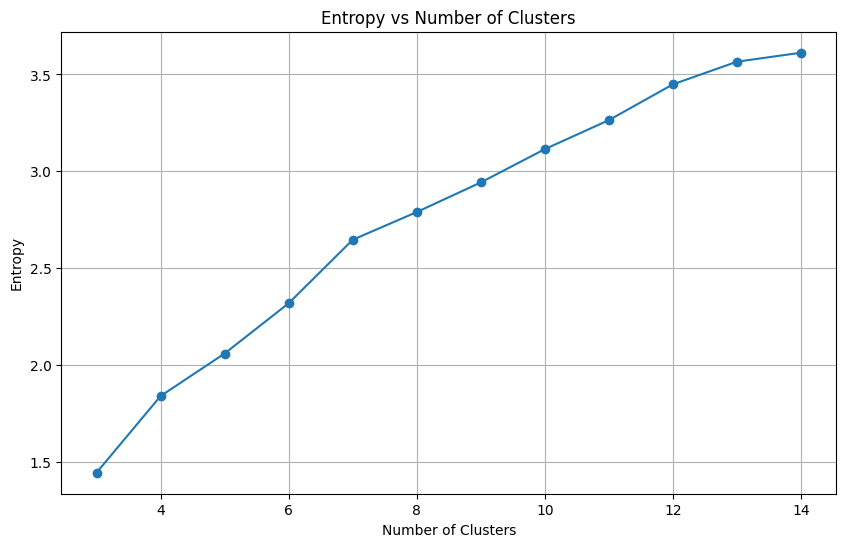

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['n_clusters'], results_df['entropy'], marker='o')
plt.title('Entropy vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Entropy')
plt.grid()
plt.show()

In [ ]:
clusterer = KMeans(n_clusters=15, n_init=10, random_state=42)
        
train_labels = clusterer.fit_predict(train_X)

In [28]:

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(train_X)

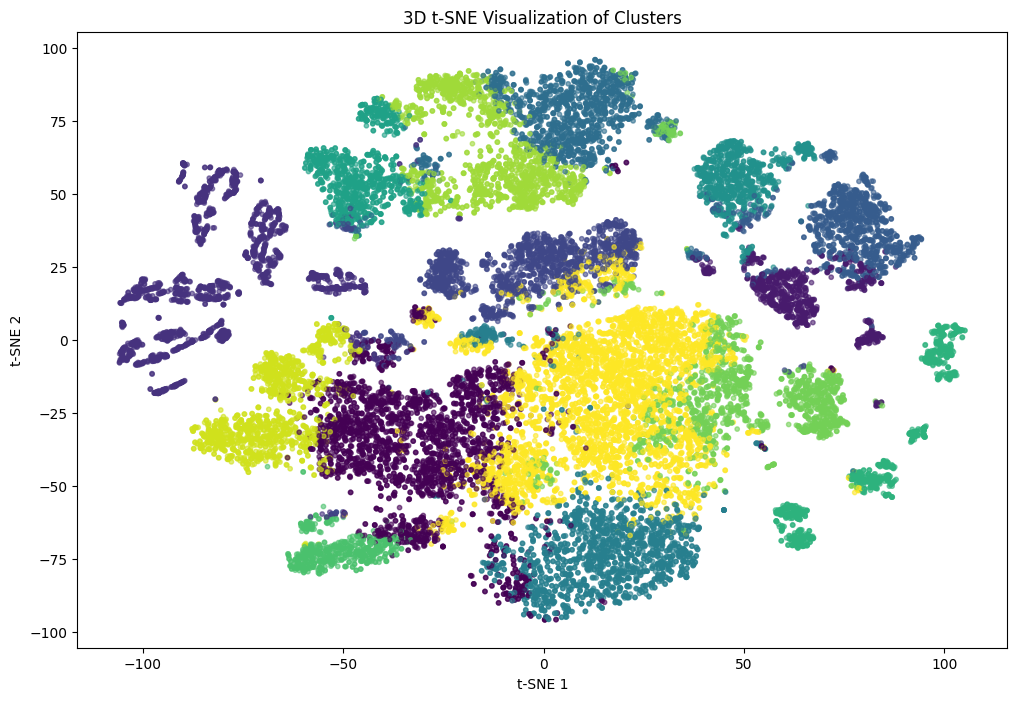

In [29]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)

scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], 
                     c=train_labels, cmap='viridis', s=10, alpha=0.6)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('3D t-SNE Visualization of Clusters')
plt.show()

In [30]:
# Add final_result back to the dataframe
data_with_clusters = data.copy()
data_with_clusters['cluster'] = train_labels

# Group by cluster and get final_result statistics
final_result_by_cluster = data_with_clusters.groupby('cluster')['final_result']



<Axes: >

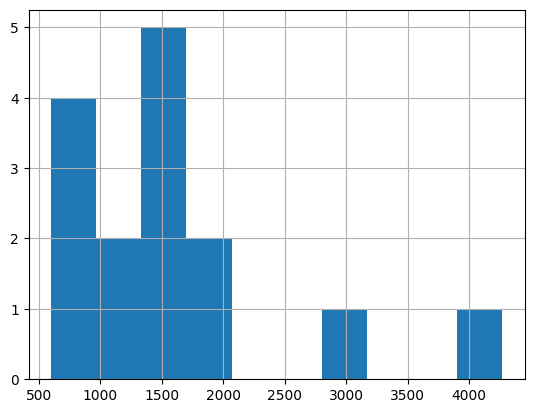

In [31]:
data_with_clusters.groupby('cluster').count()['gender'].hist(bins=10)


In [32]:
fail_or_drop_out_clusers = data_with_clusters.groupby('cluster')['final_result'].value_counts(
    normalize=True).groupby(level=0).apply(
        lambda x: x[x.index.get_level_values(1).isin([-0.5, 0])].sum()).where(
        lambda x: x > 0.666).dropna()

In [33]:
fail_or_drop_out_clusers

cluster
1     0.847059
2     0.974864
5     0.768763
9     0.980791
11    0.842926
Name: proportion, dtype: float64

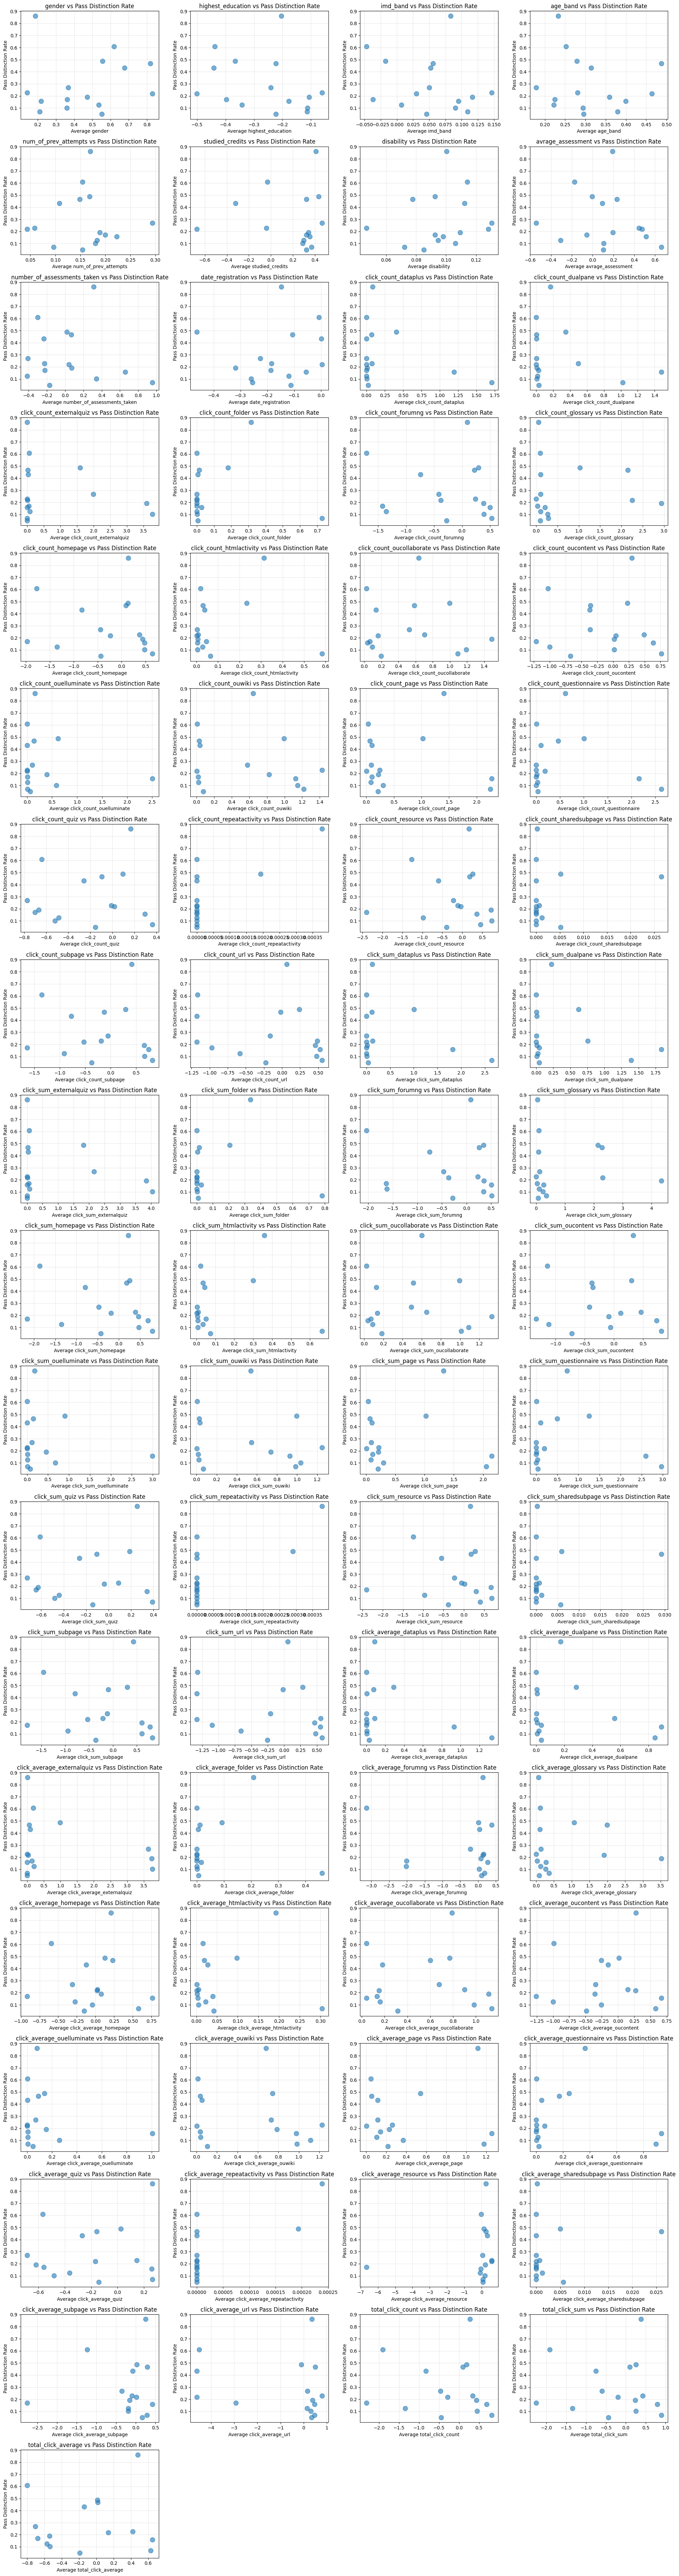

In [34]:
# Calculate pass/fail distinction rate for each cluster
cluster_stats = data_with_clusters.groupby('cluster')['final_result'].apply(
    lambda x: (x < 0).sum() / len(x)
).sort_values(ascending=False)

# Calculate cluster statistics for each column
cluster_stats_by_column = {}
for col in data.columns:
    if col != 'cluster' and col != 'final_result':
        cluster_stats_by_column[col] = data_with_clusters.groupby('cluster')[col].mean()

# Create scatter plots for each column
col_list = [col for col in data.columns if col != 'cluster' and col != 'final_result']
num_cols = len(col_list)
num_rows = (num_cols + 3) // 4  # 4 plots per row

fig, axes = plt.subplots(num_rows, 4, figsize=(20, num_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(col_list):
    axes[idx].scatter(cluster_stats_by_column[col], cluster_stats.values, s=100, alpha=0.6)
    axes[idx].set_xlabel(f'Average {col}')
    axes[idx].set_ylabel('Pass Distinction Rate')
    axes[idx].set_title(f'{col} vs Pass Distinction Rate')
    axes[idx].grid(alpha=0.3)

# Hide unused subplots
for idx in range(len(col_list), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


Correlation of features with final_result by cluster:
           gender  highest_education  imd_band  age_band  \
cluster                                                    
14       0.257356           0.140270  0.075429  0.025392   
3        0.113482           0.161061  0.081020  0.074315   
6        0.057416           0.103035  0.050810  0.015649   
11       0.106036           0.053460  0.058535 -0.032751   
0        0.084220           0.200137  0.070768  0.009838   
4        0.286008           0.041541  0.029876  0.089620   
9        0.089538          -0.005632 -0.023841  0.098258   
7        0.045392           0.118088  0.021822  0.018535   
2       -0.069434          -0.011544  0.020759  0.031877   
1        0.176602          -0.080256  0.000268 -0.072213   
13       0.049938           0.068064  0.046769 -0.017265   
5       -0.096998           0.111762  0.080286 -0.087090   
10      -0.022801           0.091334  0.157165 -0.034670   
12      -0.077858           0.133719  0.077209

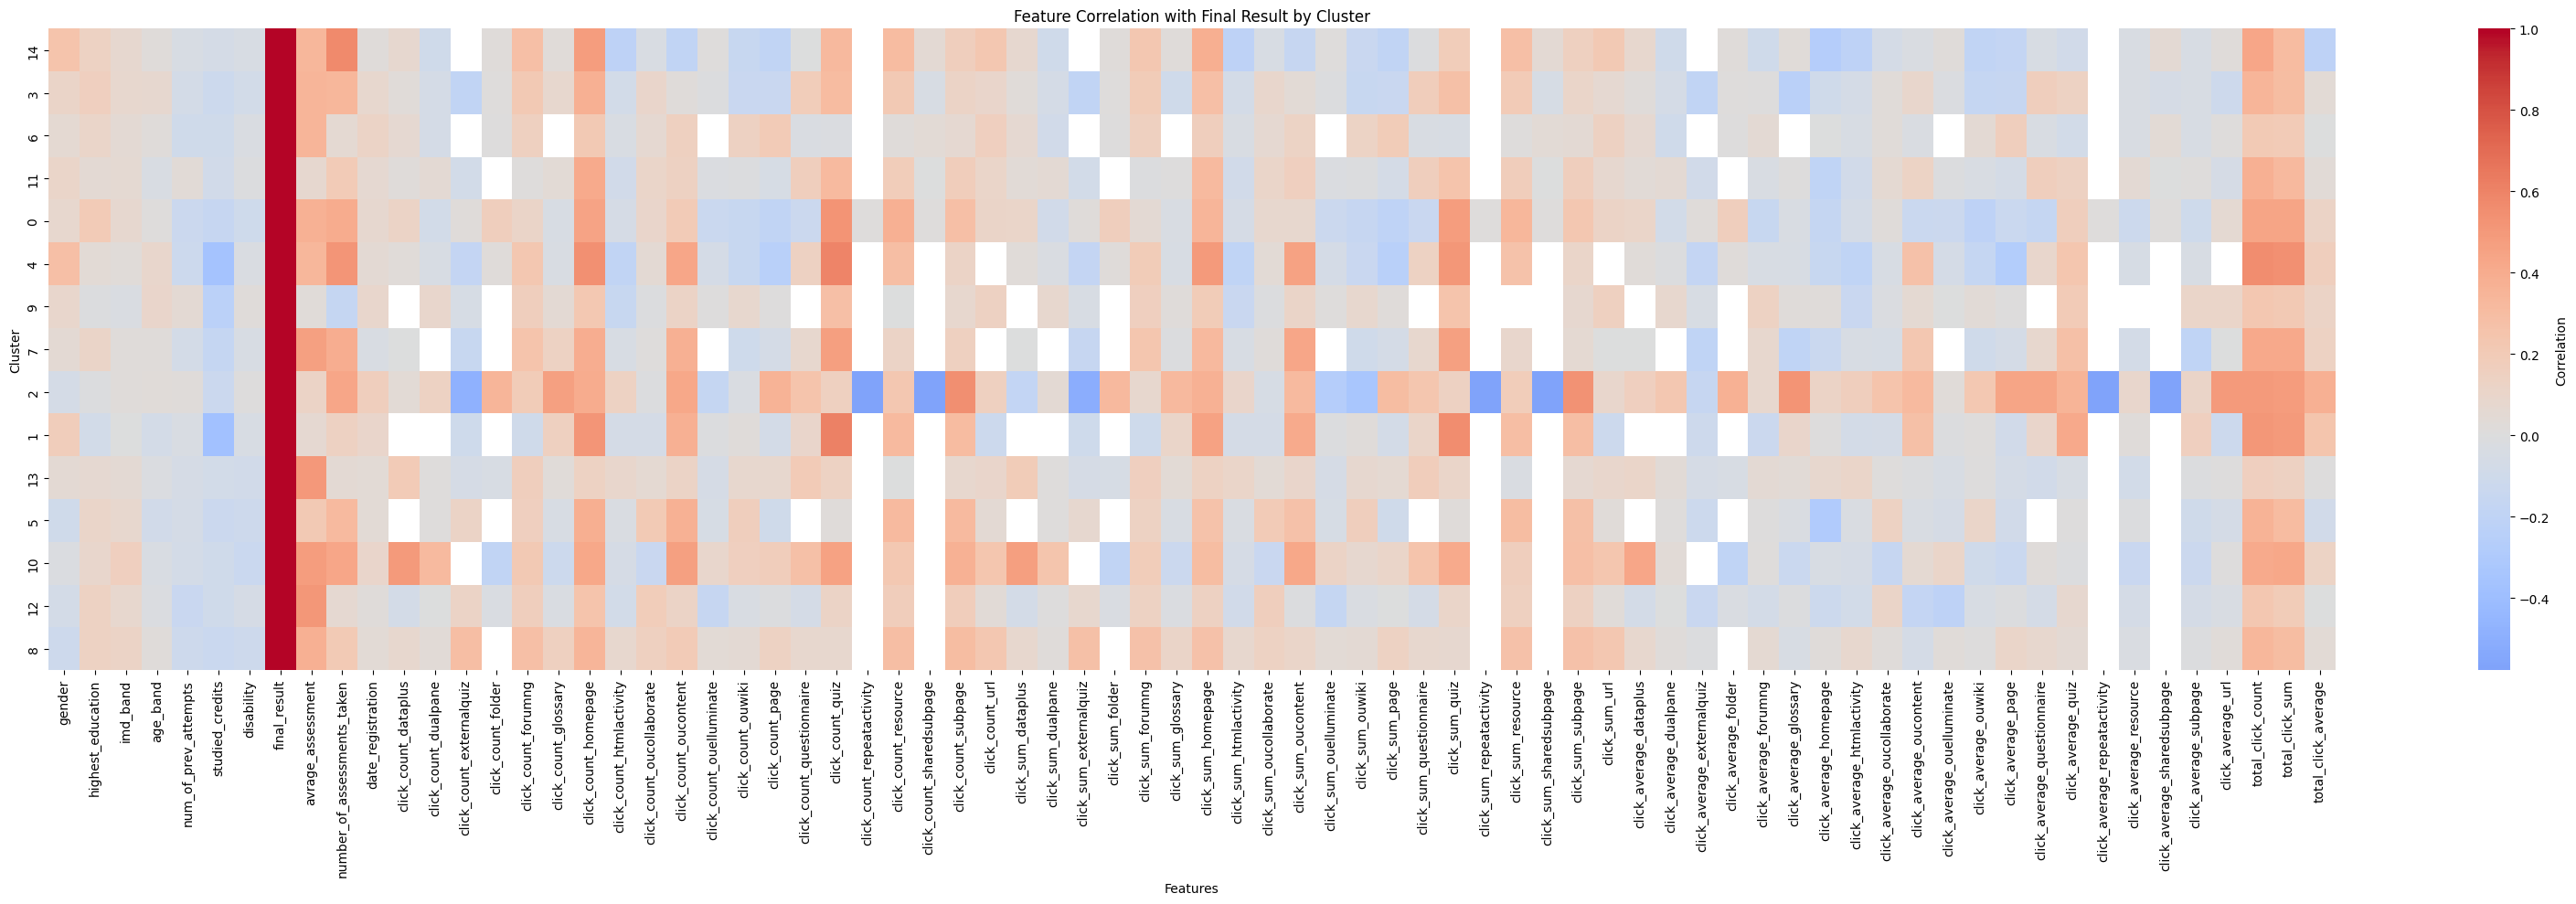

In [35]:
import seaborn as sns
# Calculate correlation for each metric with final_result by cluster
correlation_by_cluster = {}

for cluster in data_with_clusters['cluster'].unique():
    cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster]
    correlations = cluster_data.drop(columns=['cluster']).corrwith(cluster_data['final_result'])
    correlation_by_cluster[cluster] = correlations

# Convert to DataFrame for better visualization
correlation_df = pd.DataFrame(correlation_by_cluster).T
correlation_df.index.name = 'cluster'

# Display top correlated features for each cluster
print("Correlation of features with final_result by cluster:")
print(correlation_df)

# Visualize correlations as a heatmap
plt.figure(figsize=(32, 10))
sns.heatmap(correlation_df, cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation with Final Result by Cluster')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

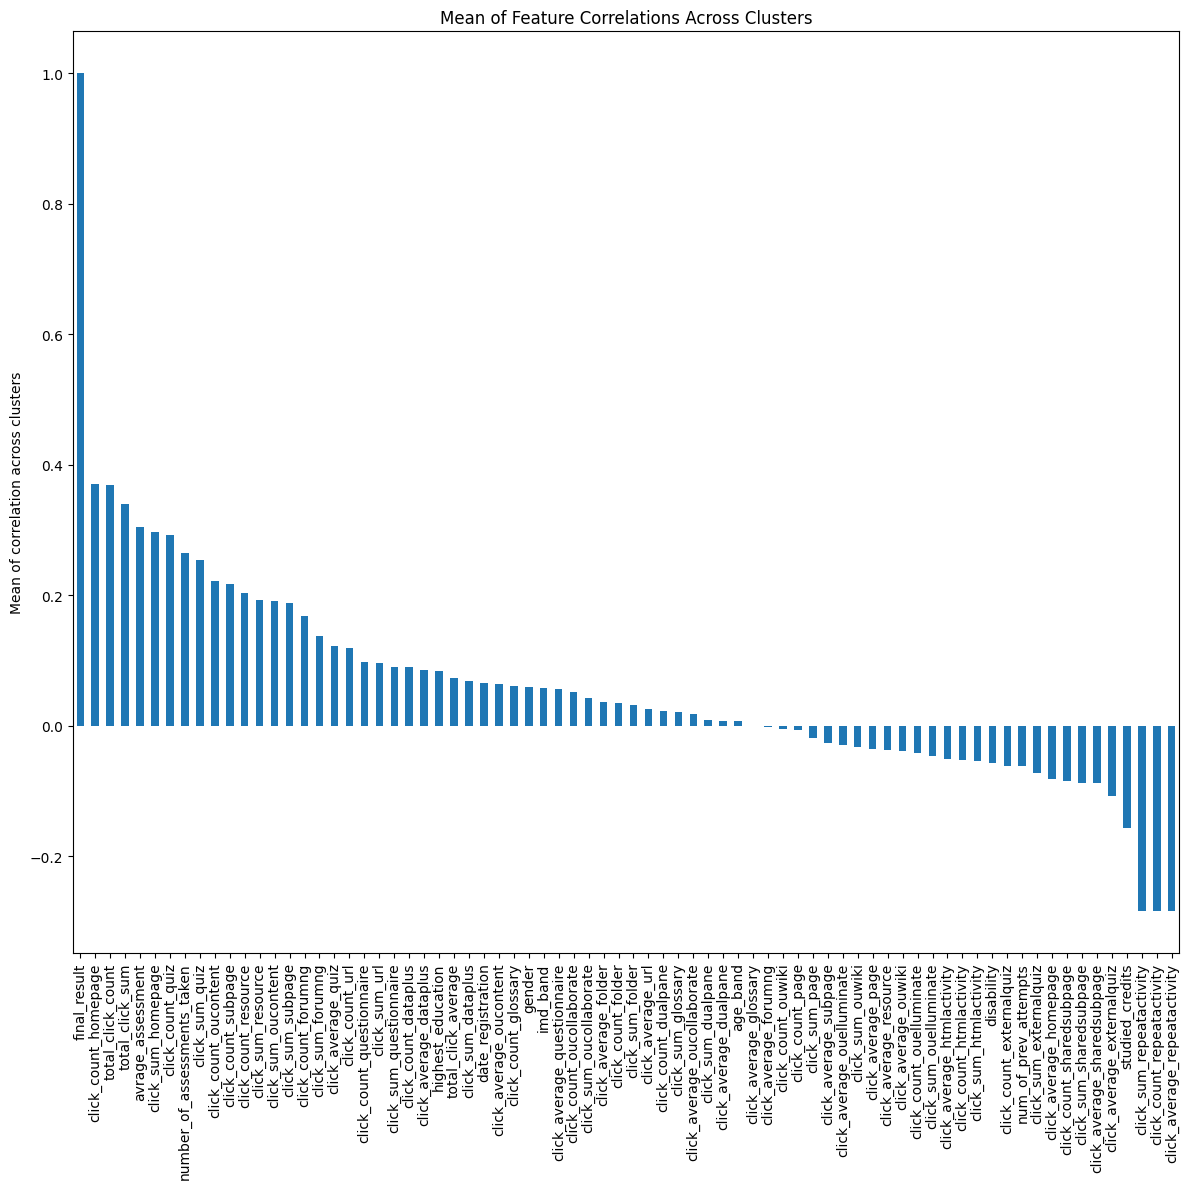

In [44]:
# Sum correlations across clusters and display vertically
mean_corr = correlation_df.mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(12, 12))
mean_corr.plot(kind='bar')
plt.ylabel('Mean of correlation across clusters')
plt.title('Mean of Feature Correlations Across Clusters')
plt.tight_layout()
plt.show()

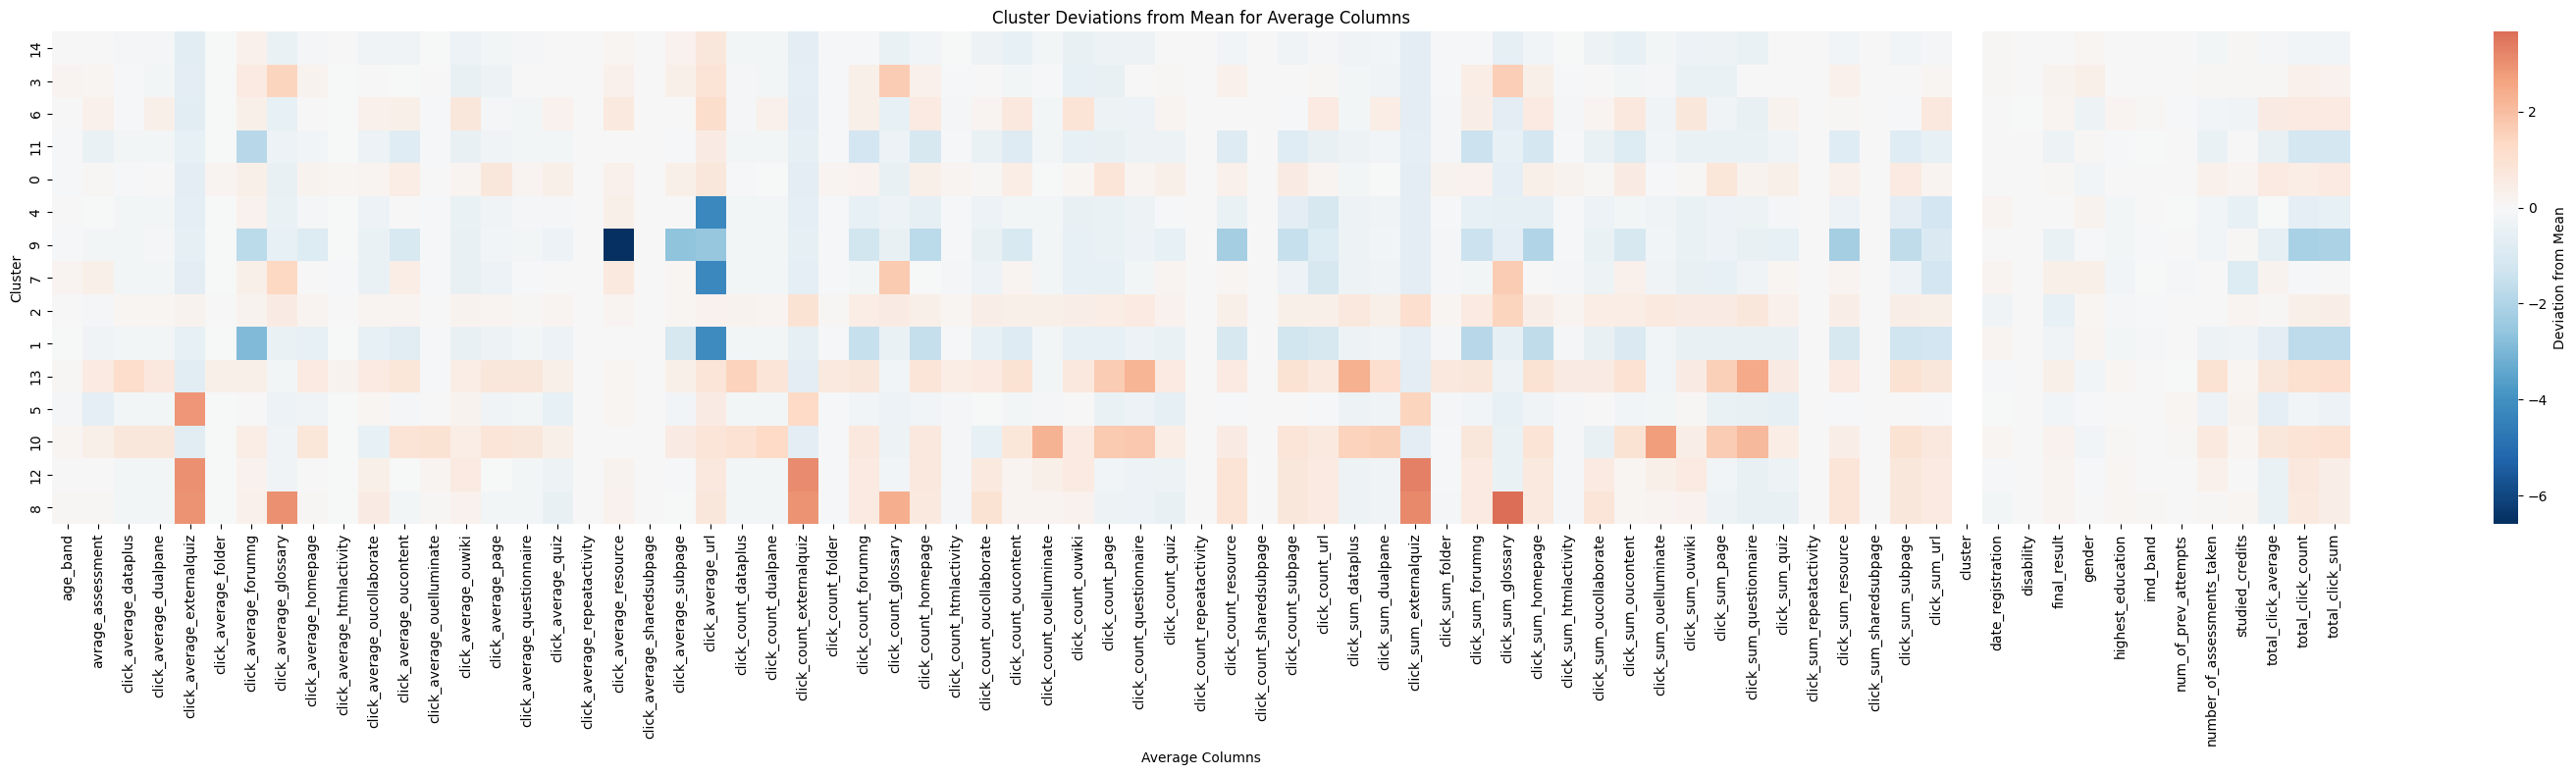

In [49]:
# Calculate deviation from mean for each cluster
cluster_deviations = {}
for cluster in data_with_clusters['cluster'].unique():
    cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster]
    deviations = cluster_data.mean() - data.mean()
    cluster_deviations[cluster] = deviations

# Create DataFrame from deviations
deviation_df = pd.DataFrame(cluster_deviations).T

# Plot heatmap
plt.figure(figsize=(30, 8))
sns.heatmap(deviation_df, cmap='RdBu_r', center=0, cbar_kws={'label': 'Deviation from Mean'}, annot=False)
plt.title('Cluster Deviations from Mean for Average Columns')
plt.xlabel('Average Columns')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [50]:
# Sort clusters by mean final_result
cluster_final_result = data_with_clusters.groupby('cluster')['final_result'].mean().sort_values(ascending=False)
print(cluster_final_result)

cluster
13    0.553689
7     0.528396
10    0.406822
3     0.394177
6     0.354207
12    0.347717
8     0.295603
0     0.224328
4     0.178185
14    0.138440
5    -0.094320
1    -0.148824
11   -0.160072
9    -0.293220
2    -0.416954
Name: final_result, dtype: float64
